# Verify the trained IDS models

This notebook loads the saved models and verifies their predictions without training again. It tests both stages:

1. **Binary detection:** benign or attack
2. **Attack classification:** the type of attack

In [1]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    f1_score, precision_score, recall_score, roc_auc_score,
)

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 160)

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

TEST_FILE = PROJECT_ROOT / 'dataset/processed/test.parquet'
FEATURE_FILE = PROJECT_ROOT / 'artifacts/feature_selection/selected_features.json'
MODEL_FOLDER = PROJECT_ROOT / 'artifacts/models'
ATTACK_MODEL_FILE = PROJECT_ROOT / 'artifacts/attack_type_model/random_forest_attack_type.joblib'

model_files = {
    'Random Forest': MODEL_FOLDER / 'random_forest.joblib',
    'Decision Tree': MODEL_FOLDER / 'decision_tree.joblib',
    'K-Nearest Neighbors': MODEL_FOLDER / 'k-nearest_neighbors.joblib',
    'Attack-type Random Forest': ATTACK_MODEL_FILE,
}

files = pd.DataFrame([
    {'model': name, 'exists': path.exists(), 'size_mb': round(path.stat().st_size / 1024**2, 2) if path.exists() else None}
    for name, path in model_files.items()
]).set_index('model')
print('Saved model files')
display(files)

required = [TEST_FILE, FEATURE_FILE, model_files['Random Forest'], ATTACK_MODEL_FILE]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError('Missing required files:\n' + '\n'.join(missing))

Saved model files


,exists,size_mb
model,,
Random Forest,True,14.86
Decision Tree,True,0.18
K-Nearest Neighbors,False,NaN
Attack-type Random Forest,True,32.65


## 1. Load and inspect the test data

In [3]:
feature_report = json.loads(FEATURE_FILE.read_text(encoding='utf-8'))
features = feature_report['selected_features']
test = pd.read_parquet(TEST_FILE, columns=features + ['is_attack', 'attack_label'])
x_test = test[features]
y_binary = test['is_attack']

print(f'Test rows:       {len(test):,}')
print(f'Input features:  {len(features)}')
print(f'Memory usage:    {test.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print('\nSelected features:')
for number, feature in enumerate(features, start=1):
    print(f'{number:2}. {feature}')

print('\nBinary class distribution:')
binary_counts = y_binary.value_counts().rename(index={0: 'Benign', 1: 'Attack'})
display(pd.DataFrame({'rows': binary_counts, 'percent': binary_counts / len(test) * 100}).round(2))

print('Attack-label distribution:')
attack_counts = test['attack_label'].value_counts()
display(pd.DataFrame({'rows': attack_counts, 'percent': attack_counts / len(test) * 100}).round(3))

Test rows:       504,160
Input features:  20
Memory usage:    45.8 MB

Selected features:
 1. Packet Length Variance
 2. Packet Length Std
 3. Bwd Packet Length Std
 4. Average Packet Size
 5. Avg Bwd Segment Size
 6. Packet Length Mean
 7. Bwd Packet Length Max
 8. Bwd Packet Length Mean
 9. Max Packet Length
10. Destination Port
11. Fwd IAT Std
12. Fwd IAT Max
13. Flow IAT Max
14. Subflow Bwd Bytes
15. Total Length of Bwd Packets
16. Flow IAT Std
17. Idle Max
18. Fwd Packet Length Max
19. Init_Win_bytes_backward
20. Idle Mean

Binary class distribution:


,rows,percent
is_attack,,
Benign,419012,83.11
Attack,85148,16.89


Attack-label distribution:


,rows,percent
attack_label,,
BENIGN,419012,83.111
DoS Hulk,34681,6.879
DDoS,25632,5.084
PortScan,18186,3.607
DoS GoldenEye,1968,0.39
FTP - Patator,1129,0.224
DoS slowloris,1101,0.218
DoS Slowhttptest,986,0.196
SSH - Patator,635,0.126


## 2. Load and verify the binary models

The loaded models are set to one CPU thread only for predictable notebook execution. This does not change their learned parameters.

In [4]:
binary_models = {}
for name in ['Random Forest', 'Decision Tree', 'K-Nearest Neighbors']:
    path = model_files[name]
    if not path.exists():
        print(f'Skipping {name}: saved model was not found')
        continue

    model = joblib.load(path)
    if hasattr(model, 'n_jobs'):
        model.n_jobs = 1
    if hasattr(model, 'named_steps') and 'kneighborsclassifier' in model.named_steps:
        model.named_steps['kneighborsclassifier'].n_jobs = 1
    binary_models[name] = model

    print(f'\n{name}')
    print(f'  Python type:       {type(model).__name__}')
    print(f'  Learned classes:   {list(model.classes_)}')
    print(f'  Expected features: {model.n_features_in_}')
    assert model.n_features_in_ == len(features)
    assert set(model.classes_) == {0, 1}

print(f'\nSuccessfully loaded {len(binary_models)} binary model(s).')


Random Forest
  Python type:       RandomForestClassifier
  Learned classes:   [np.int8(0), np.int8(1)]
  Expected features: 20

Decision Tree
  Python type:       DecisionTreeClassifier
  Learned classes:   [np.int8(0), np.int8(1)]
  Expected features: 20
Skipping K-Nearest Neighbors: saved model was not found

Successfully loaded 2 binary model(s).


In [5]:
binary_results = []
binary_outputs = {}

for name, model in binary_models.items():
    start = time.perf_counter()
    probabilities = model.predict_proba(x_test)
    attack_column = list(model.classes_).index(1)
    attack_probability = probabilities[:, attack_column]
    predictions = model.classes_[np.argmax(probabilities, axis=1)]
    prediction_seconds = time.perf_counter() - start

    assert len(predictions) == len(test)
    assert probabilities.shape == (len(test), 2)
    np.testing.assert_allclose(probabilities.sum(axis=1), 1.0, atol=1e-6)

    binary_results.append({
        'model': name,
        'accuracy': accuracy_score(y_binary, predictions),
        'precision': precision_score(y_binary, predictions, zero_division=0),
        'recall': recall_score(y_binary, predictions, zero_division=0),
        'f1': f1_score(y_binary, predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_binary, attack_probability),
        'errors': int((predictions != y_binary.to_numpy()).sum()),
        'prediction_seconds': prediction_seconds,
    })
    binary_outputs[name] = {
        'predictions': predictions,
        'attack_probability': attack_probability,
    }

binary_results = pd.DataFrame(binary_results).set_index('model')
print('Binary model results on the complete test set')
display(binary_results.round(5))

Binary model results on the complete test set


,accuracy,precision,recall,f1,roc_auc,errors,prediction_seconds
model,,,,,,,
Random Forest,0.99650,0.98430,0.99516,0.98970,0.99991,1764,2.91766
Decision Tree,0.99509,0.97395,0.99760,0.98564,0.99925,2476,0.03663



Random Forest classification report
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    419012
      Attack       0.98      1.00      0.99     85148

    accuracy                           1.00    504160
   macro avg       0.99      1.00      0.99    504160
weighted avg       1.00      1.00      1.00    504160



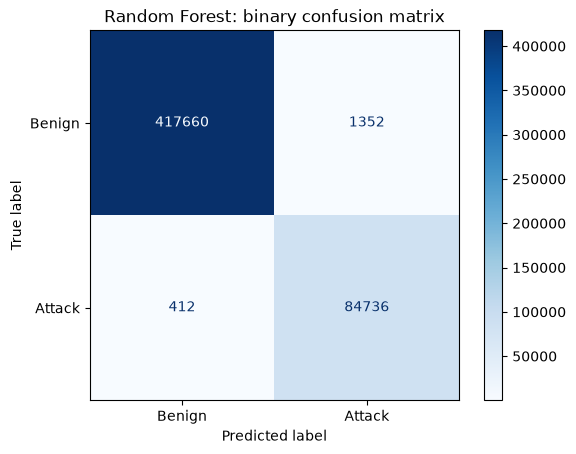


Decision Tree classification report
              precision    recall  f1-score   support

      Benign       1.00      0.99      1.00    419012
      Attack       0.97      1.00      0.99     85148

    accuracy                           1.00    504160
   macro avg       0.99      1.00      0.99    504160
weighted avg       1.00      1.00      1.00    504160



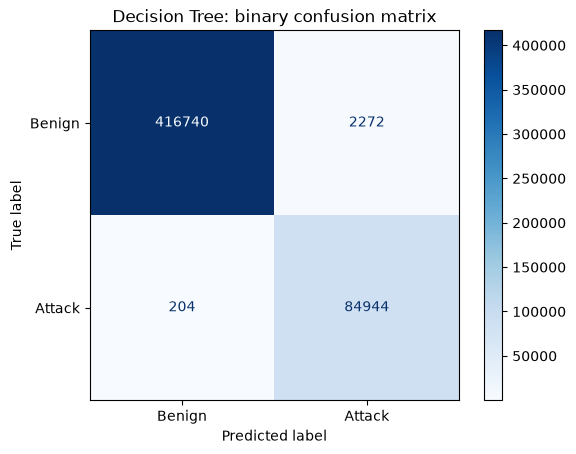

In [6]:
for name, output in binary_outputs.items():
    print(f'\n{name} classification report')
    print(classification_report(
        y_binary, output['predictions'], target_names=['Benign', 'Attack'], zero_division=0
    ))
    ConfusionMatrixDisplay.from_predictions(
        y_binary, output['predictions'], display_labels=['Benign', 'Attack'], cmap='Blues'
    )
    plt.title(f'{name}: binary confusion matrix')
    plt.show()

### Inspect individual binary predictions

These rows include correct predictions and errors. Confidence is the probability of the predicted class.

In [7]:
main_output = binary_outputs['Random Forest']
binary_view = test[['attack_label', 'is_attack']].copy()
binary_view['predicted_is_attack'] = main_output['predictions']
binary_view['attack_probability'] = main_output['attack_probability']
binary_view['confidence'] = np.where(
    binary_view['predicted_is_attack'] == 1,
    binary_view['attack_probability'],
    1 - binary_view['attack_probability'],
)
binary_view['correct'] = binary_view['is_attack'] == binary_view['predicted_is_attack']

correct_examples = binary_view[binary_view['correct']].sample(10, random_state=42)
error_examples = binary_view[~binary_view['correct']].head(10)
examples = pd.concat([correct_examples, error_examples]).reset_index(names='test_row')
display(examples.round({'attack_probability': 4, 'confidence': 4}))

,test_row,attack_label,is_attack,predicted_is_attack,attack_probability,confidence,correct
0,301172,BENIGN,0,0,0.0000,1.0000,True
1,31287,BENIGN,0,0,0.0425,0.9575,True
2,1234,BENIGN,0,0,0.0000,1.0000,True
3,52573,DoS Hulk,1,1,1.0000,1.0000,True
4,234671,PortScan,1,1,0.9957,0.9957,True
5,468723,BENIGN,0,0,0.0000,1.0000,True
6,153160,BENIGN,0,0,0.0000,1.0000,True
7,227414,BENIGN,0,0,0.4697,0.5303,True
8,361865,DDoS,1,1,1.0000,1.0000,True
9,63442,BENIGN,0,0,0.0000,1.0000,True


## 3. Load and verify the attack-type model

In [8]:
attack_model = joblib.load(ATTACK_MODEL_FILE)
attack_model.n_jobs = 1
attack_test = test[test['is_attack'] == 1].copy()
x_attack = attack_test[features]
y_attack = attack_test['attack_label']

print(f'Model type:          {type(attack_model).__name__}')
print(f'Expected features:   {attack_model.n_features_in_}')
print(f'Attack test rows:    {len(attack_test):,}')
print(f'Number of classes:   {len(attack_model.classes_)}')
print('Learned attack classes:')
for name in attack_model.classes_:
    print(f'  - {name}')

assert attack_model.n_features_in_ == len(features)
assert 'BENIGN' not in attack_model.classes_
assert set(y_attack.unique()).issubset(set(attack_model.classes_))

Model type:          RandomForestClassifier
Expected features:   20
Attack test rows:    85,148
Number of classes:   14
Learned attack classes:
  - Bot
  - DDoS
  - DoS GoldenEye
  - DoS Hulk
  - DoS Slowhttptest
  - DoS slowloris
  - FTP - Patator
  - Heartbleed
  - Infiltration
  - PortScan
  - SSH - Patator
  - Web Attack - Brute Force
  - Web Attack - Sql Injection
  - Web Attack - XSS


In [9]:
start = time.perf_counter()
attack_probabilities = attack_model.predict_proba(x_attack)
attack_predictions = attack_model.classes_[np.argmax(attack_probabilities, axis=1)]
attack_prediction_seconds = time.perf_counter() - start
attack_confidence = attack_probabilities.max(axis=1)

assert len(attack_predictions) == len(attack_test)
assert attack_probabilities.shape == (len(attack_test), len(attack_model.classes_))
np.testing.assert_allclose(attack_probabilities.sum(axis=1), 1.0, atol=1e-6)

attack_metrics = pd.Series({
    'accuracy': accuracy_score(y_attack, attack_predictions),
    'precision_macro': precision_score(y_attack, attack_predictions, average='macro', zero_division=0),
    'recall_macro': recall_score(y_attack, attack_predictions, average='macro', zero_division=0),
    'f1_macro': f1_score(y_attack, attack_predictions, average='macro', zero_division=0),
    'f1_weighted': f1_score(y_attack, attack_predictions, average='weighted', zero_division=0),
    'errors': int((attack_predictions != y_attack.to_numpy()).sum()),
    'prediction_seconds': attack_prediction_seconds,
}, name='value')
print('Attack-type model results')
display(attack_metrics.to_frame().round(5))

per_class = pd.DataFrame(classification_report(
    y_attack, attack_predictions, labels=attack_model.classes_,
    output_dict=True, zero_division=0,
)).transpose()
print('Per-class results')
display(per_class.round(4))

Attack-type model results


,value
accuracy,0.99658
precision_macro,0.87253
recall_macro,0.89555
f1_macro,0.87775
f1_weighted,0.99694
errors,291.00000
prediction_seconds,1.23009


Per-class results


,precision,recall,f1-score,support
Bot,1.0000,1.0000,1.0000,384.0000
DDoS,0.9999,0.9998,0.9998,25632.0000
DoS GoldenEye,0.9929,0.9949,0.9939,1968.0000
DoS Hulk,0.9993,0.9975,0.9984,34681.0000
DoS Slowhttptest,0.9959,0.9939,0.9949,986.0000
DoS slowloris,0.9937,0.9973,0.9955,1101.0000
FTP - Patator,1.0000,1.0000,1.0000,1129.0000
Heartbleed,1.0000,1.0000,1.0000,3.0000
Infiltration,1.0000,1.0000,1.0000,6.0000
PortScan,0.9996,0.9996,0.9996,18186.0000


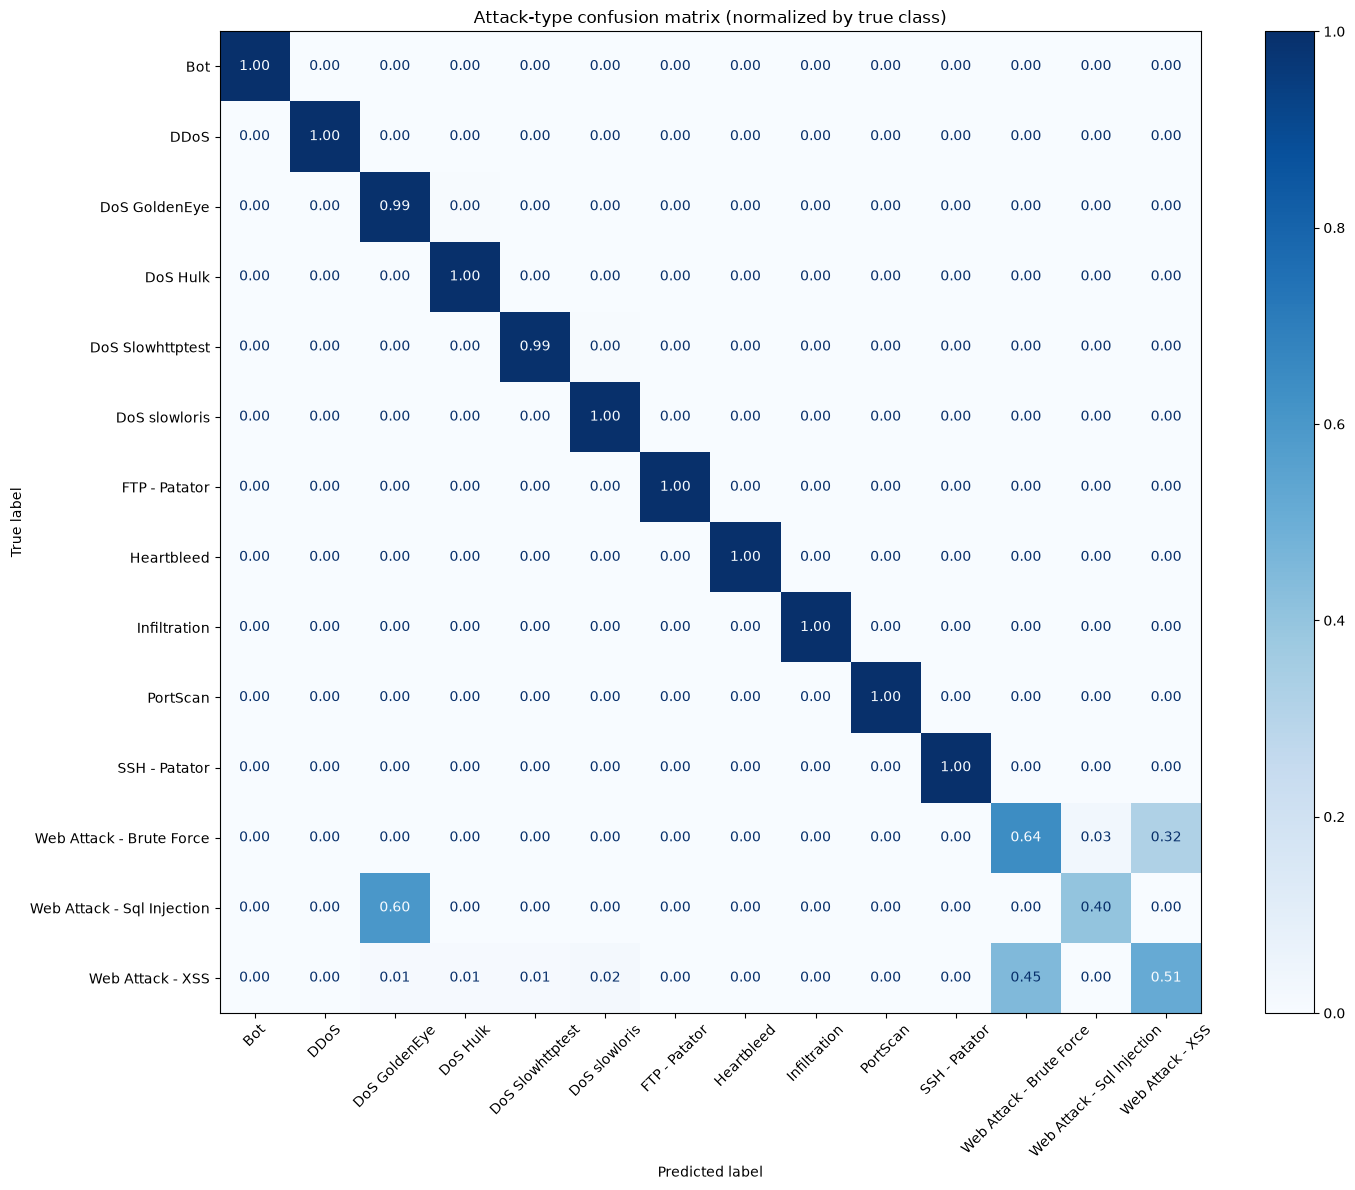

In [10]:
figure, axis = plt.subplots(figsize=(15, 12))
ConfusionMatrixDisplay.from_predictions(
    y_attack, attack_predictions, labels=attack_model.classes_,
    display_labels=attack_model.classes_, normalize='true', values_format='.2f',
    cmap='Blues', xticks_rotation=45, ax=axis,
)
axis.set_title('Attack-type confusion matrix (normalized by true class)')
plt.tight_layout()
plt.show()

### Inspect attack-type predictions and errors

In [11]:
attack_view = pd.DataFrame({
    'actual_attack': y_attack.to_numpy(),
    'predicted_attack': attack_predictions,
    'confidence': attack_confidence,
}, index=attack_test.index)
attack_view['correct'] = attack_view['actual_attack'] == attack_view['predicted_attack']

examples_by_class = attack_view.groupby('actual_attack').head(2)
print('Two examples from every true attack class')
display(examples_by_class.reset_index(names='test_row').round({'confidence': 4}))

errors = attack_view[~attack_view['correct']]
print(f'Total attack-type errors: {len(errors):,}')
print('Most common confusion pairs:')
display(errors.groupby(['actual_attack', 'predicted_attack']).size().sort_values(ascending=False).head(20).to_frame('rows'))
print('First 20 incorrect predictions:')
display(errors.head(20).reset_index(names='test_row').round({'confidence': 4}))

Two examples from every true attack class


,test_row,actual_attack,predicted_attack,confidence,correct
0,2,DDoS,DDoS,1.0000,True
1,3,DDoS,DDoS,1.0000,True
2,22,DoS GoldenEye,DoS GoldenEye,1.0000,True
3,27,PortScan,PortScan,1.0000,True
4,37,DoS Hulk,DoS Hulk,1.0000,True
5,38,PortScan,PortScan,1.0000,True
6,48,DoS Hulk,DoS Hulk,1.0000,True
7,73,DoS GoldenEye,DoS GoldenEye,1.0000,True
8,549,FTP - Patator,FTP - Patator,1.0000,True
9,602,DoS Slowhttptest,DoS Slowhttptest,0.9992,True


Total attack-type errors: 291
Most common confusion pairs:


,,rows
actual_attack,predicted_attack,
Web Attack - Brute Force,Web Attack - XSS,101
DoS Hulk,Web Attack - XSS,69
Web Attack - XSS,Web Attack - Brute Force,53
Web Attack - Brute Force,Web Attack - Sql Injection,9
DoS GoldenEye,DoS Hulk,8
PortScan,DoS Hulk,7
DoS Hulk,DoS GoldenEye,7
DDoS,DoS Hulk,6
DoS Hulk,PortScan,6


First 20 incorrect predictions:


,test_row,actual_attack,predicted_attack,confidence,correct
0,3039,DoS GoldenEye,DoS Hulk,0.8834,False
1,3968,DDoS,DoS Hulk,0.5108,False
2,4035,Web Attack - Brute Force,Web Attack - XSS,0.7041,False
3,6144,Web Attack - Brute Force,Web Attack - XSS,0.6962,False
4,6582,Web Attack - XSS,DoS Hulk,0.8788,False
5,9558,DoS Hulk,Web Attack - XSS,0.3627,False
6,9780,DoS slowloris,DoS GoldenEye,0.5533,False
7,11917,Web Attack - Brute Force,Web Attack - XSS,0.6773,False
8,12329,DoS Hulk,DoS GoldenEye,0.7802,False
9,15367,Web Attack - XSS,Web Attack - Brute Force,0.8908,False


## 4. Verify the complete two-stage IDS

The binary Random Forest runs first. Only flows predicted as attacks are passed to the attack-type model.

In [12]:
binary_predictions = main_output['predictions']
final_predictions = np.full(len(test), 'BENIGN', dtype=object)
predicted_attack_rows = np.flatnonzero(binary_predictions == 1)
final_predictions[predicted_attack_rows] = attack_model.predict(x_test.iloc[predicted_attack_rows])

final_accuracy = accuracy_score(test['attack_label'], final_predictions)
final_macro_f1 = f1_score(test['attack_label'], final_predictions, average='macro', zero_division=0)
final_errors = int((final_predictions != test['attack_label'].to_numpy()).sum())

print('Complete IDS results')
print(f'  Test rows:                 {len(test):,}')
print(f'  Predicted attack rows:     {len(predicted_attack_rows):,}')
print(f'  Final 15-class accuracy:   {final_accuracy:.4%}')
print(f'  Final 15-class macro F1:   {final_macro_f1:.4f}')
print(f'  Incorrect final labels:    {final_errors:,}')

final_view = pd.DataFrame({
    'actual_label': test['attack_label'],
    'predicted_label': final_predictions,
    'binary_attack_probability': main_output['attack_probability'],
})
final_view['correct'] = final_view['actual_label'] == final_view['predicted_label']
print('Example final errors:')
display(final_view[~final_view['correct']].head(25).round({'binary_attack_probability': 4}))

Complete IDS results
  Test rows:                 504,160
  Predicted attack rows:     86,088
  Final 15-class accuracy:   99.6108%
  Final 15-class macro F1:   0.7998
  Incorrect final labels:    1,962
Example final errors:


,actual_label,predicted_label,binary_attack_probability,correct
60,BENIGN,Web Attack - XSS,0.5819,False
133,DoS Hulk,BENIGN,0.2618,False
339,BENIGN,Web Attack - Brute Force,0.5941,False
627,BENIGN,Web Attack - Brute Force,0.5723,False
725,BENIGN,Bot,0.5621,False
826,DoS Hulk,BENIGN,0.4697,False
930,BENIGN,DoS Hulk,0.6676,False
955,BENIGN,Web Attack - Brute Force,0.5247,False
1054,SSH - Patator,BENIGN,0.3703,False
1061,BENIGN,Web Attack - Brute Force,0.5796,False


## Interpretation checklist

- **Recall** shows how many attacks were detected.
- **Precision** shows how often an attack alert was correct.
- **Macro F1** gives rare and common attack types equal importance.
- **Weighted F1** is dominated by common classes, so it can look excellent even when rare classes are weak.
- Very small test classes, such as Heartbleed and SQL Injection, do not provide stable performance estimates.